<a href="https://colab.research.google.com/github/paulinaniemczak/Machine-Learning/blob/master/Lab10-convolutional-neural-network-CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 10 - Convolutional Neural Network, CNN

### Author: Szymon Nowakowski


# Presentation on Convolutional Layers
--------------------

We shall start off by going through a [short presentation on convolusional layers](https://github.com/SzymonNowakowski/Machine-Learning-2025/blob/master/convolutional_layers.pdf). It is best to first download it and then go through it in a slide-show layout.

# Reading MNIST Dataset
----------------------------------

In [1]:
import torch
import torchvision
from matplotlib import pyplot

transform = torchvision.transforms.Compose(
    [ torchvision.transforms.ToTensor(), #Converts a PIL Image or numpy.ndarray (H x W x C) in the range [0, 255] to a torch.FloatTensor of shape (C x H x W) in the range [0.0, 1.0]
      torchvision.transforms.Normalize((0.1307), (0.3081))])

trainset = torchvision.datasets.MNIST(root='./data',
                                      train=True,
                                      download=True,
                                      transform=transform)

trainloader = torch.utils.data.DataLoader(trainset,
                                          batch_size=2048,
                                          shuffle=True)   #we do shuffle it to give more randomizations to training epochs

testset = torchvision.datasets.MNIST(root='./data',
                                     train=False,
                                     download=True,
                                     transform=transform)

testloader = torch.utils.data.DataLoader(testset,
                                         batch_size=1,
                                         shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.4MB/s]


# Tensor Sizes
-------------------

Recall:
- Batched labels are of order one. The first (and only) index is a sample index within a batch.
- Image batches have order 4. The first order is a batch order, but a second order has dimensionality of 1 and thus it can be indexed by 0 only.
  - This index represents a Channel number inserted here by `ToTensor()` transformation, always 0.
  - This singleton order should be retained because we want to use convolutional layers, which explicitly require this order. For RGB images we have 3 channels, for B&W images we have only one channel.


# CNN Definition
-----------------



## Task

Your job now is to code the definition of the LeNet5 neural network. You can find the definition [here](https://en.wikipedia.org/wiki/LeNet#/media/File:Comparison_image_neural_networks.svg).


In [8]:
import torch.nn as nn
import torch.nn.functional as F

class LeNet5(torch.nn.Module):
    def __init__(self):
        super().__init__()

        # TODO: add missing layers
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)

        # 16x4x4 for our data
        self.fc1 = nn.Linear(in_features=16*5*5, out_features=120)
        self.fc2 = nn.Linear(in_features=120, out_features=84)
        self.fc3 = nn.Linear(in_features=84, out_features=10)


        self.dropout = torch.nn.Dropout(0.05)


    def forward(self, x):
        # print("input:", x.shape)
        # TODO: add missing processing

        # convolution with sigmoid
        x = torch.sigmoid(self.conv1(x))
        # print("conv1:", x.shape)

        # pooling
        x = F.avg_pool2d(x, kernel_size=2, stride=2)
        # print("pool1:", x.shape)

        # convolution with sigmoid 2
        x = torch.sigmoid(self.conv2(x))
        # print("conv2:", x.shape)

        # pooling
        x = F.avg_pool2d(x, kernel_size=2, stride=2)
        # print("pool2:", x.shape)

        # flatten
        x = torch.flatten(x, start_dim=1)
        # print("flatten:", x.shape)

        # linear
        x = torch.sigmoid(self.fc1(x))
        # print("fc1:", x.shape)

        # linear
        x = torch.sigmoid(self.fc2(x))

        # last
        x = self.fc3(x)

        # convolution
        x = self.dropout(x)
        return x

# Training Loop
----------------------

In [9]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Working on {device}")

net = LeNet5().to(device)
optimizer = torch.optim.Adam(net.parameters(), 0.001)   #initial and fixed learning rate of 0.001.

net.train()    #it notifies the network layers (especially batchnorm or dropout layers, which we don't use in this example) that we are doing traning
for epoch in range(16):  #  an epoch is a training run through the whole data set

    for batch, data in enumerate(trainloader):
        batch_inputs, batch_labels = data

        batch_inputs = batch_inputs.to(device)  #explicitly moving the data to the target device
        batch_labels = batch_labels.to(device)

        # print(batch_inputs.shape)
        # print(batch_labels.shape)

        optimizer.zero_grad()

        batch_outputs = net(batch_inputs)   #this line calls the forward(self, x) method of the LeNet5 object. Please note,
                                            # the nonlinear activation after the last layer is NOT applied
        loss = torch.nn.functional.cross_entropy(batch_outputs, batch_labels, reduction = "mean") #instead, nonlinear softmax is applied internally in THIS loss function
        print("epoch:", epoch, "batch:", batch, "current batch loss:", loss.item())
        loss.backward()       #this computes gradients as we have seen in previous workshops
        optimizer.step()     #but this line in fact updates our neural network.
                                ####You can experiment - comment this line and check, that the loss DOE

Working on cuda
epoch: 0 batch: 0 current batch loss: 2.3622124195098877
epoch: 0 batch: 1 current batch loss: 2.3386707305908203
epoch: 0 batch: 2 current batch loss: 2.324347972869873
epoch: 0 batch: 3 current batch loss: 2.313007116317749
epoch: 0 batch: 4 current batch loss: 2.3033721446990967
epoch: 0 batch: 5 current batch loss: 2.3018476963043213
epoch: 0 batch: 6 current batch loss: 2.3043670654296875
epoch: 0 batch: 7 current batch loss: 2.30432391166687
epoch: 0 batch: 8 current batch loss: 2.3065881729125977
epoch: 0 batch: 9 current batch loss: 2.3023104667663574
epoch: 0 batch: 10 current batch loss: 2.3099563121795654
epoch: 0 batch: 11 current batch loss: 2.3156962394714355
epoch: 0 batch: 12 current batch loss: 2.30527925491333
epoch: 0 batch: 13 current batch loss: 2.3039071559906006
epoch: 0 batch: 14 current batch loss: 2.3054208755493164
epoch: 0 batch: 15 current batch loss: 2.304619550704956
epoch: 0 batch: 16 current batch loss: 2.302652359008789
epoch: 0 batch: 

# Testing
----------------------

In [10]:
good = 0
wrong = 0

net.eval()              #it notifies the network layers (especially batchnorm or dropout layers, which we don't use in this example) that we are doing evaluation
with torch.no_grad():   #it prevents that the net learns during evalution. The gradients are not computed, so this makes it faster, too
    for batch, data in enumerate(testloader): #batches in test are of size 1
        datapoint, label = data

        prediction = net(datapoint.to(device))                  #prediction has values representing the "prevalence" of the corresponding class
        classification = torch.argmax(prediction)    #the class is the index of maximal "prevalence"

        if classification.item() == label.item():
            good += 1
        else:
            wrong += 1

print("accuracy = ", good/(good+wrong))

accuracy =  0.9433


# Understanding Kernel Size, Stride and Padding

## Task: Designing a Convolutional Neural Network with a Target Receptive Field

Design a convolutional neural network using only 3×3 or 5×5 convolutional layers and 2×2 max-pooling layers without overlap (i.e., with stride 2). Use no padding in any layer. Insert a max-pooling layer after every two or three convolutional layers.

Your goal is to construct an architecture such that the receptive field of each output neuron is approximately 60×60 pixels.


In [5]:
import torch.nn as nn
import torch.nn.functional as F

# input size is 400x400

class field_net(torch.nn.Module):
  def __init__(self):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3)
    self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
    self.conv3 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3)
    self.conv4 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=5)
    self.conv5 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=5)
    self.conv6 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3)
    self.conv7 = nn.Conv2d(in_channels=256, out_channels=512, kernel_size=3)


    self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

  def forward(self, x):
    x = self.conv1(x)
    x = F.relu(x)
    x = self.conv2(x)
    x = F.relu(x)

    x = self.pool(x)

    x = self.conv3(x)
    x = F.relu(x)
    x = self.conv4(x)
    x = F.relu(x)

    x = self.pool(x)
    x = self.conv5(x)
    x = F.relu(x)
    x = self.conv6(x)
    x = F.relu(x)

    x = self.pool(x)
    x = self.conv7(x)

    return x

**Answers**

Compute the receptive field size of the final output layer.
**66**

Compute the effective stride of the output layer with respect to the input.
**8**

Assuming an input image size of 400×400, determine the spatial size of the output feature map.
**42x42x512**

Q: Where would you locate ReLU layers?
**After every convolutional layer, so the nonlinearity is introduced and the learning is improved.**

Q: What if we can't match the desired input size with our architecture?
**The architecture can be slightly modified by adding or removing convolutional layer or changing the kernel size.**

Q: Discuss what possible impact padding can have on the network performance.
**Padding preserves spatial size of output feature map and prevents border information loss, but also adds artificial information that may slightly affect feature extraction.**

# **Homework Assignment – Adversarial Examples**

In this assignment, you will explore how small (invisible to humans) changes to real digits can _fool_ the CNN into misclassifying them, even though the changes are imperceptible to humans.



## Task 1 – CNN Dreams: Last Homework Assignment Revisited

Re-run the input optimization process (for NN dreams) from the previous MLP-class homework assignment, but this time using the **LeNet-5 CNN model** we trained in this class.


1. Starting from ten random noise images, optimize the input so that each image is classified with high confidence as one of the digits 0 through 9.
2. Include an **L2 penalty** on the input to keep the images visually closer to realistic digits. Use a range of penalty strengths (e.g., $\lambda_{l2}$ = 0, and then 0.01 through 10.0).
3. Compare the generated images (with and without L2 penalty) to those generated by the MLP:
   - Are they more or less readable?
   - Do they resemble real MNIST digits more closely or less?
   - Why do you think that happens? Consider the CNN’s inductive biases and architectural properties.

Use `cross_entropy_loss + lambda_l2 * input.pow(2).mean()` as your objective.

Reuse your code: visualize confidence evolution during optimization and generate image grids and (optionally) animations showing how the inputs evolve.




iteration: 0 loss: 4.214388370513916 mean confidence: 0.05647175386548042
iteration: 25 loss: 0.018228506669402122 mean confidence: 0.9819715619087219
iteration: 50 loss: 0.014221133664250374 mean confidence: 0.9858884215354919
iteration: 75 loss: 0.013029071502387524 mean confidence: 0.9870619773864746
iteration: 100 loss: 0.012375910766422749 mean confidence: 0.9877066016197205
iteration: 125 loss: 0.011913353577256203 mean confidence: 0.988163411617279
iteration: 150 loss: 0.011553781107068062 mean confidence: 0.9885188937187195
iteration: 175 loss: 0.011262434534728527 mean confidence: 0.9888069033622742
iteration: 200 loss: 0.011020859703421593 mean confidence: 0.9890459179878235
iteration: 225 loss: 0.01081754732877016 mean confidence: 0.9892470240592957
iteration: 250 loss: 0.010644333437085152 mean confidence: 0.9894184470176697
iteration: 275 loss: 0.010495198890566826 mean confidence: 0.9895660281181335


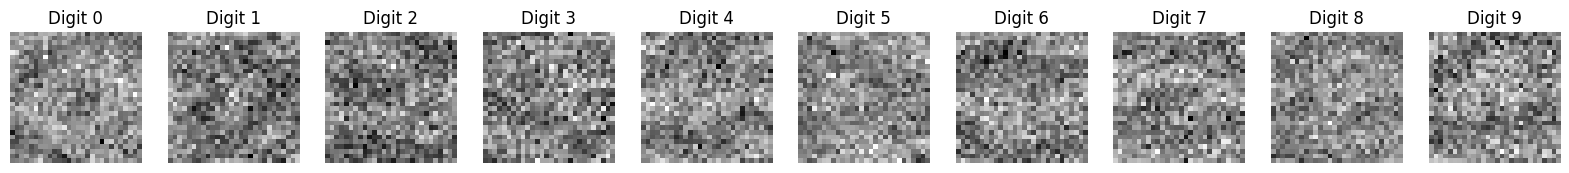

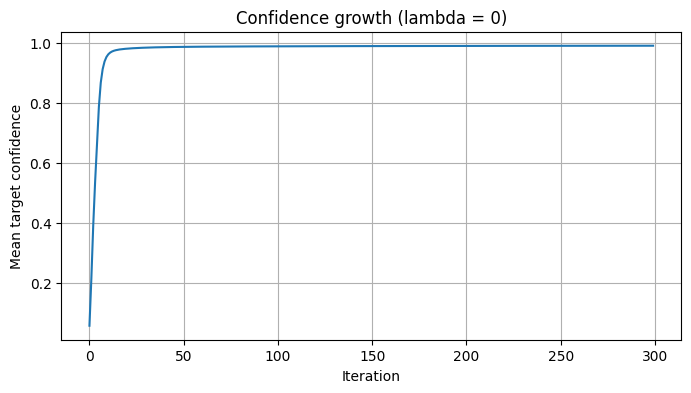

iteration: 0 loss: 4.419934272766113 mean confidence: 0.07581207156181335
iteration: 25 loss: 0.029127661138772964 mean confidence: 0.9825848937034607
iteration: 50 loss: 0.025920910760760307 mean confidence: 0.9859439134597778
iteration: 75 loss: 0.024371713399887085 mean confidence: 0.9872549176216125
iteration: 100 loss: 0.02340872213244438 mean confidence: 0.9879243969917297
iteration: 125 loss: 0.02265113964676857 mean confidence: 0.9883781671524048
iteration: 150 loss: 0.02200281247496605 mean confidence: 0.9887223243713379
iteration: 175 loss: 0.02143128216266632 mean confidence: 0.9889932870864868
iteration: 200 loss: 0.020919058471918106 mean confidence: 0.989210307598114
iteration: 225 loss: 0.02045253850519657 mean confidence: 0.9893884658813477
iteration: 250 loss: 0.020021021366119385 mean confidence: 0.9895387887954712
iteration: 275 loss: 0.019617311656475067 mean confidence: 0.9896690249443054


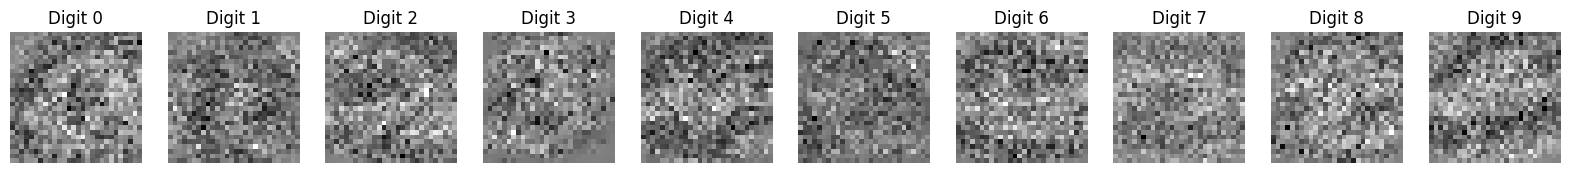

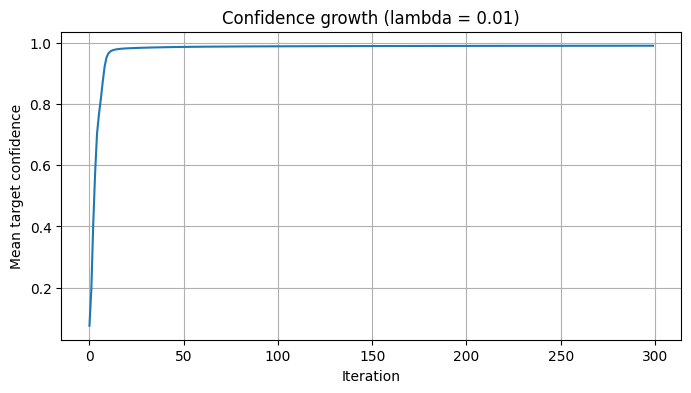

iteration: 0 loss: 4.707205772399902 mean confidence: 0.07981333136558533
iteration: 25 loss: 0.12789469957351685 mean confidence: 0.9808832406997681
iteration: 50 loss: 0.11181055754423141 mean confidence: 0.986314594745636
iteration: 75 loss: 0.09840993583202362 mean confidence: 0.9874062538146973
iteration: 100 loss: 0.08717326074838638 mean confidence: 0.9879627227783203
iteration: 125 loss: 0.07772359251976013 mean confidence: 0.9883268475532532
iteration: 150 loss: 0.06967945396900177 mean confidence: 0.9885872006416321
iteration: 175 loss: 0.0627685934305191 mean confidence: 0.9887838363647461
iteration: 200 loss: 0.05679348483681679 mean confidence: 0.9889381527900696
iteration: 225 loss: 0.05160451680421829 mean confidence: 0.989061176776886
iteration: 250 loss: 0.04708409681916237 mean confidence: 0.989159107208252
iteration: 275 loss: 0.043136127293109894 mean confidence: 0.9892365336418152


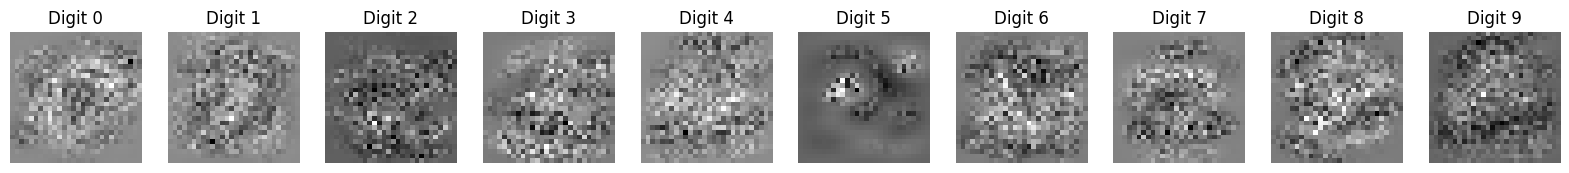

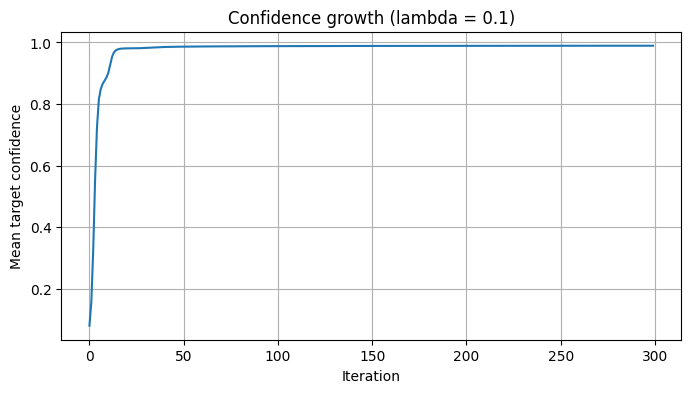

iteration: 0 loss: 5.204745292663574 mean confidence: 0.10402470827102661
iteration: 25 loss: 0.7353060245513916 mean confidence: 0.9829910397529602
iteration: 50 loss: 0.4060995578765869 mean confidence: 0.9866496920585632
iteration: 75 loss: 0.22867132723331451 mean confidence: 0.9866966605186462
iteration: 100 loss: 0.13929301500320435 mean confidence: 0.9859119653701782
iteration: 125 loss: 0.09194941818714142 mean confidence: 0.9854177832603455
iteration: 150 loss: 0.06603322178125381 mean confidence: 0.9848540425300598
iteration: 175 loss: 0.051471784710884094 mean confidence: 0.9844858050346375
iteration: 200 loss: 0.043003737926483154 mean confidence: 0.9843124747276306
iteration: 225 loss: 0.03790321946144104 mean confidence: 0.9842348098754883
iteration: 250 loss: 0.034742049872875214 mean confidence: 0.9841999411582947
iteration: 275 loss: 0.03273708373308182 mean confidence: 0.9841833114624023


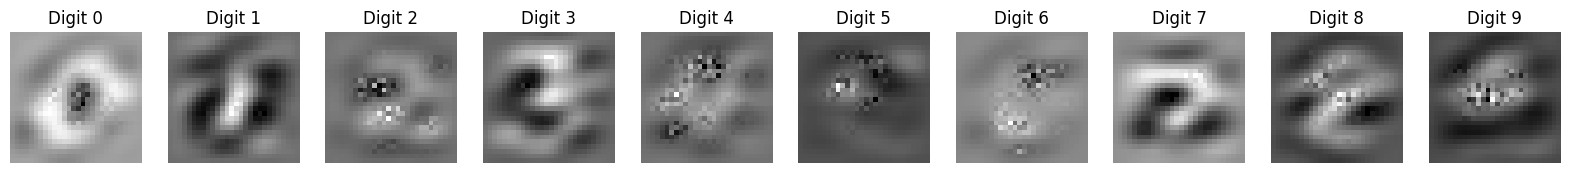

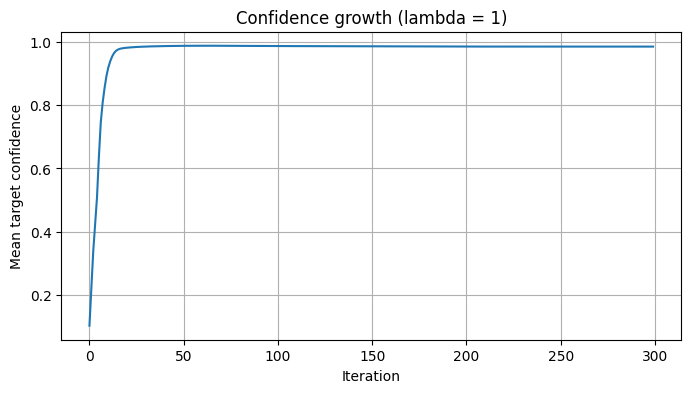

iteration: 0 loss: 13.726156234741211 mean confidence: 0.1407434195280075
iteration: 25 loss: 2.1289422512054443 mean confidence: 0.9686996340751648
iteration: 50 loss: 0.36707600951194763 mean confidence: 0.9574124217033386
iteration: 75 loss: 0.13764868676662445 mean confidence: 0.9622975587844849
iteration: 100 loss: 0.10784512758255005 mean confidence: 0.9631282687187195
iteration: 125 loss: 0.10384216904640198 mean confidence: 0.9632627367973328
iteration: 150 loss: 0.10332527756690979 mean confidence: 0.963283360004425
iteration: 175 loss: 0.1032608225941658 mean confidence: 0.9632884860038757
iteration: 200 loss: 0.10325285792350769 mean confidence: 0.963290810585022
iteration: 225 loss: 0.1032518595457077 mean confidence: 0.963291347026825
iteration: 250 loss: 0.10325177758932114 mean confidence: 0.963291585445404
iteration: 275 loss: 0.10325175523757935 mean confidence: 0.963291585445404


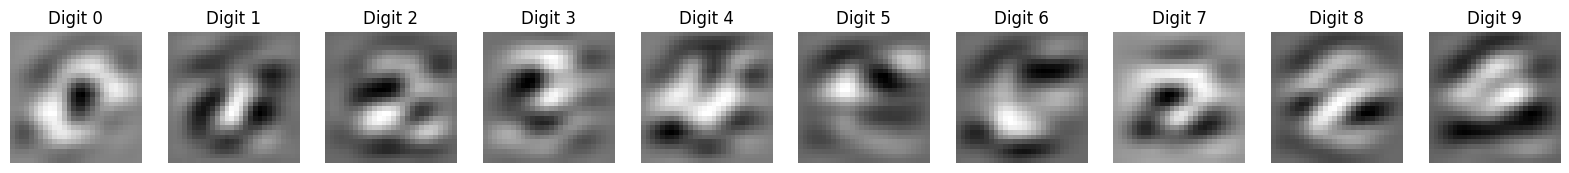

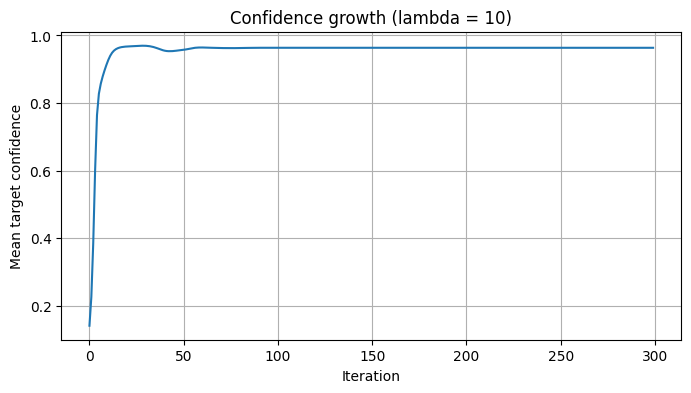

In [11]:
"""enhanced code from previous lab"""
net.eval() # LeNet-5 without training behaviors

for param in net.parameters():
  param.requires_grad = False # without weights' training

target_labels = torch.arange(10).to(device) # target labels for images from 0 to 9, tensor shape: 10


lambda_values = [0, 0.01, 0.1, 1, 10]
for lambda_l2 in lambda_values:
  dream_batch_input = torch.randn(10, 1, 28, 28, device=device) # batch of random noise images, shape: batch size, channels (grayscale, so 1), height, width
  dream_batch_input.requires_grad_(True) # gradient for input images
  dream_optimizer = torch.optim.Adam([dream_batch_input], lr=0.05) # updates input images

  iterations = 300
  confidence_history = []

  for iteration in range(iterations):
    dream_optimizer.zero_grad() # reset gradient from previous iteration

    outputs = net(dream_batch_input) # pass images

    cross_entropy = F.cross_entropy(outputs, target_labels) # cross-entropy loss, digit named by their digit
    l2 = dream_batch_input.pow(2).mean()
    loss = cross_entropy + lambda_l2 * l2 # total loss

    loss.backward() # gradients
    dream_optimizer.step() # update images using gradients

    probabilities = torch.softmax(outputs, dim=1)
    target_confidence = probabilities[torch.arange(10), target_labels] # confidence of given class

    confidence_history.append(target_confidence.mean().item()) # save confidence for later visualisation


    if iteration % 25 == 0:
      print(
          "iteration:", iteration,
          "loss:", loss.item(),
          "mean confidence:", target_confidence.mean().item()
      )


  # plotting
  images = dream_batch_input.detach().cpu() # moves tensor to cpu

  figure, axes = pyplot.subplots(1, 10, figsize=(20, 2))
  for i in range(10):
    image = images[i][0]
    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(f"Digit {i}")
    axes[i].axis("off")
  pyplot.show()


  """ confidence growth during optimization """
  pyplot.figure(figsize=(8, 4))
  pyplot.plot(confidence_history)
  pyplot.title(f"Confidence growth (lambda = {lambda_l2})")
  pyplot.xlabel("Iteration")
  pyplot.ylabel("Mean target confidence")
  pyplot.grid()
  pyplot.show()


## Task 2 – Adversarial Examples: Fooling LeNet-5

This is the core focus of the assignment.

Using a batch of **real MNIST digits** (e.g., nine examples per class), craft **adversarial examples** by adding subtle, trained noise to the input images. Your goal is to:

- **Keep the human-perceived digit the same** (e.g., a "7" should still look like a "7"),
- But **cause LeNet-5 to misclassify it** – as every other class different from the original, hence nine examples per class.

### Objective
For each image $x$ and its true label $y$, learn a perturbation $\delta$ such that:

- $\text{LeNet5}(x + \delta) = y_{\text{wrong}} $,
- and $ \|\delta\|_2 $ is as small as possible (penalize large perturbations), to keep $x + \delta$ *look* like $x$ for humans.

### Optimization
Use gradient-based optimization on $\delta$ (the noise), while keeping the network weights frozen. Your loss might look like:

```
loss = cross_entropy(model(x + delta), target_wrong_class) +
       lambda_l2 * delta.pow(2).mean()
```

Tune the $\lambda_{l2}$ to find the best range.

### Deliverables for the Second Task
- Select some best examples, showing the original digit and its (correct) classification and the perturbed digit (hopefully, still looking the same to humans) and how it gets misclassified. Show them side by side.
- Report:
  - Success rate of attacks (it doesn't need to be very formal),
  - Effect of $\lambda_{l2}$ on visibility of the noise and success of misclassification,
  - Example image grids and confidence plots.



## Deliverables for the Homework Assignment
- A Google Colab notebook with:
  - Complete implementation for both tasks.
  - Visualizations and animations (animations are optional but encouraged).
  - Clear written analysis of your findings.
- Upload the notebook and results to your GitHub repository for the course.
- Include a link to the notebook and video (if applicable) in the `README.md`.
- In the notebook, include “Open in Colab” badge so it can be launched directly.

In [12]:
import torch
import torchvision

testset = torchvision.datasets.MNIST(root='./data',
                                      train=False,
                                      download=True,
                                      transform=transform)

image, label = testset[0]
print("image.shape:", image.shape)
print("label:", label)

# input as batch
image = image.unsqueeze(0).to(device)
print("image.shape:", image.shape)

# delta
delta = torch.zeros_like(image, requires_grad=True)
print("delta.shape:", delta.shape)

prediction = net(image + delta)



""""""
net.eval() # LeNet-5 without training behaviors

for param in net.parameters():
  param.requires_grad = False # without weights' training

target_wrong_class = torch.tensor([1]).to(device)

loss = cross_entropy(net(image + delta), target_wrong_class) +\
        lambda_l2 * delta.pow(2).mean()

lambda_values = [0, 0.01, 0.1, 1, 10]
for lambda_l2 in lambda_values:

  dream_optimizer = torch.optim.Adam([delta], lr=0.05) # updates input images

  iterations = 300
  confidence_history = []

  for iteration in range(iterations):
    dream_optimizer.zero_grad() # reset gradient from previous iteration

    outputs = net(image + delta) # pass images

    cross_entropy = F.cross_entropy(outputs, target_wrong_class) # cross-entropy loss, digit named by their digit
    l2 = (image + delta).pow(2).mean()
    loss = cross_entropy + lambda_l2 * l2 # total loss

    loss.backward() # gradients
    dream_optimizer.step() # update images using gradients

    probabilities = torch.softmax(outputs, dim=1)
    target_confidence = probabilities[torch.arange(10), target_labels] # confidence of given class


    confidence_history.append(target_confidence.mean().item()) # save confidence for later visualisation


    if iteration % 25 == 0:
      print(
          "iteration:", iteration,
          "loss:", loss.item(),
          "mean confidence:", target_confidence.mean().item()
      )


  # plotting
  images = (image + delta).detach().cpu() # moves tensor to cpu

  figure, axes = pyplot.subplots(1, 10, figsize=(20, 2))
  for i in range(10):
    image = images[i][0]
    axes[i].imshow(image, cmap="gray")
    axes[i].set_title(f"Digit {i}")
    axes[i].axis("off")
  pyplot.show()


  """ confidence growth during optimization """
  pyplot.figure(figsize=(8, 4))
  pyplot.plot(confidence_history)
  pyplot.title(f"Confidence growth (lambda = {lambda_l2})")
  pyplot.xlabel("Iteration")
  pyplot.ylabel("Mean target confidence")
  pyplot.grid()
  pyplot.show()






image.shape: torch.Size([1, 28, 28])
label: 7
image.shape: torch.Size([1, 1, 28, 28])
delta.shape: torch.Size([1, 1, 28, 28])


TypeError: 'Tensor' object is not callable